## Setup

In [1]:
import pandas as pd
import sys
import os

# Add src to system path
sys.path.append(os.path.abspath(os.path.join('..')))
import selection
from data_analysis import eda

# Load the features generated by the pipeline
df = pd.read_csv("../../output/features.csv")

print(f"Original feature count: {len(df.columns)}")

Original feature count: 42


## Testing the Selection Function

In [2]:
# Test the function with the threshold identified during EDA
# We exclude 'pathology' and 'assessment' as they are targets/metadata
exclude_list = ['id', 'patient_id', 'pathology', 'assessment']

df_reduced, dropped_cols = selection.drop_high_correlation_features(
    df, 
    threshold=0.90, 
    exclude=exclude_list
)

print(f"\nNumber of features dropped: {len(dropped_cols)}")
print(f"Number of remaining features: {len(df_reduced.columns)}")
print(f"\nRemaining features: {df_reduced.columns}")

Dropped 28 redundant features due to high correlation (> 0.9): ['Area Bounding Box', 'Area Convex', 'Area Filled', 'Axis Major Length', 'Axis Minor Length', 'Centroid X', 'Centroid Y', 'Equivalent Diameter', 'Feret Diameter Max', 'Perimeter', 'Aspect Ratio', 'Convexity', 'Irregularity Index', 'Roundness', 'Shape Factor', 'Relative Area', 'Hu Moment 1', 'Hu Moment 2', 'Hu Moment 3', 'original_shape2D_Elongation', 'original_shape2D_MajorAxisLength', 'original_shape2D_MaximumDiameter', 'original_shape2D_MeshSurface', 'original_shape2D_MinorAxisLength', 'original_shape2D_Perimeter', 'original_shape2D_PerimeterSurfaceRatio', 'original_shape2D_PixelSurface', 'original_shape2D_Sphericity']

Number of features dropped: 28
Number of remaining features: 14

Remaining features: Index(['id', 'patient_id', 'assessment', 'pathology', 'Area', 'Eccentricity',
       'Extent', 'Solidity', 'Orientation', 'Circularity', 'Hu Moment 4',
       'Hu Moment 5', 'Hu Moment 6', 'Hu Moment 7'],
      dtype='obje

## Verification

In [3]:
# Verify that specific redundant features like 'Perimeter' or 'Area Convex' were removed
# based on your previous correlation report
for col in ['Perimeter', 'Area Convex', 'Area Bounding Box']:
    if col in dropped_cols:
        print(f"Success: {col} was correctly identified as redundant.")

Success: Perimeter was correctly identified as redundant.
Success: Area Convex was correctly identified as redundant.
Success: Area Bounding Box was correctly identified as redundant.


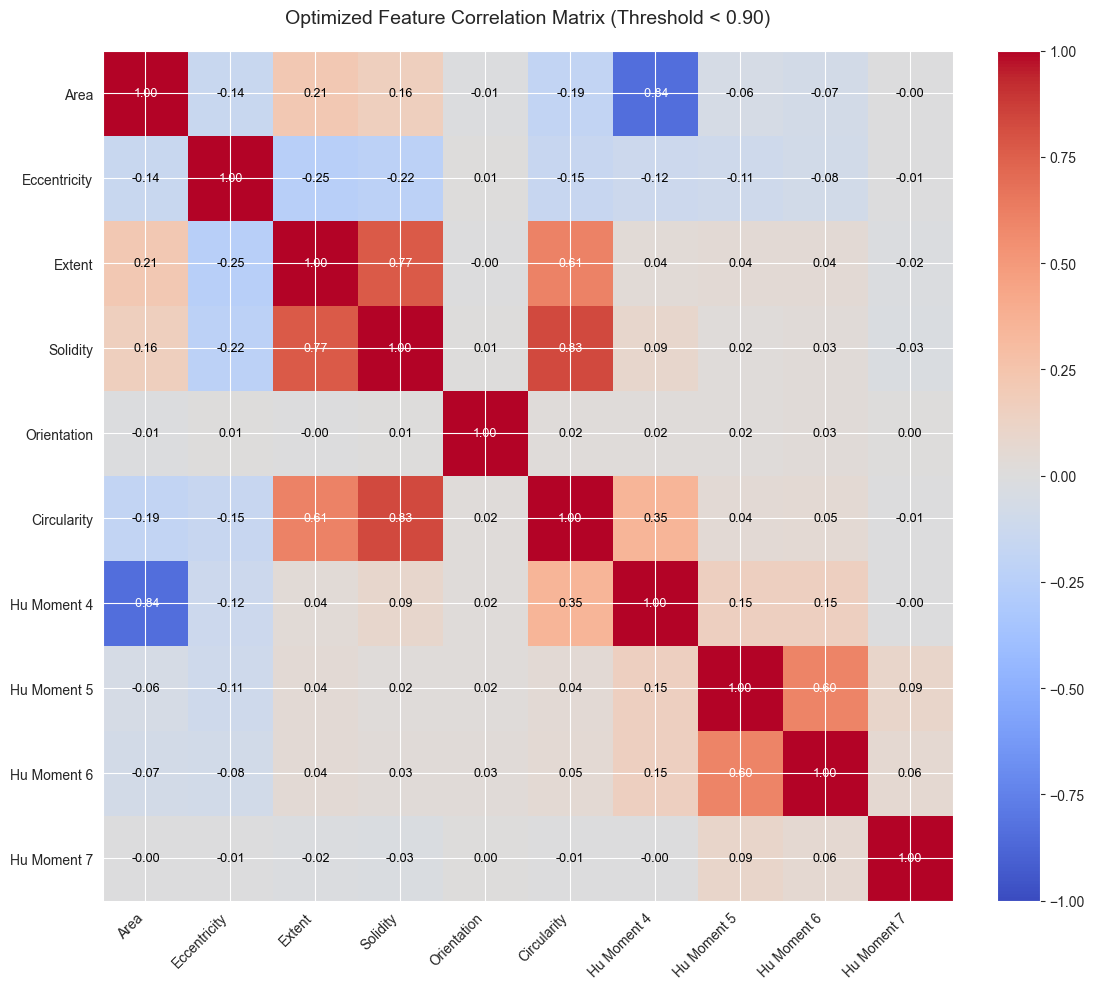

Final set of features for model training: ['Area', 'Eccentricity', 'Extent', 'Solidity', 'Orientation', 'Circularity', 'Hu Moment 4', 'Hu Moment 5', 'Hu Moment 6', 'Hu Moment 7']


In [4]:
# 1. Dynamically identify numeric features remaining after selection
# We exclude metadata and target columns to focus only on the predictors
exclude_metadata = ['id', 'patient_id', 'pathology', 'assessment']
remaining_numeric_features = [col for col in df_reduced.columns if col not in exclude_metadata]

# 2. Call the eda module to plot the new correlation matrix
# This ensures we use the same Spearman method and visualization style as before
eda.plot_correlation_matrix(
    df_reduced, 
    remaining_numeric_features, 
    title="Optimized Feature Correlation Matrix (Threshold < 0.90)",
    save_path="../../output/optimized_correlation_matrix.png"
)

# 3. Final summary of the feature reduction
print(f"Final set of features for model training: {remaining_numeric_features}")